In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os
from sklearn.model_selection import StratifiedGroupKFold

# ------------------ 1. Загрузка данных из обработанного CSV ------------------
DATA_PATH = 'data/processed/siddha_processed.csv'
df = pd.read_csv(DATA_PATH)  # колонки: user_id, activity, timestamp, gyro_x, gyro_y, gyro_z, acc_x, acc_y, acc_z

# Убедимся, что нет пропусков и нулевых временных меток (на всякий случай)
df = df.dropna()
#df = df[df['timestamp'] != 0]

# Сортируем по пользователю и времени (уже должно быть, но гарантируем)
df = df.sort_values(['user_id', 'activity', 'timestamp']).reset_index(drop=True)

# ------------------ 2. Создание окон ------------------
WINDOW_SIZE = 200
STEP = 100  # перекрытие 50%

# Признаки: все, кроме user_id, activity, timestamp
feature_cols = ['gyro_x', 'gyro_y', 'gyro_z', 'acc_x', 'acc_y', 'acc_z']

X_windows = []    # окна (WINDOW_SIZE, 6)
y_windows = []    # метки активности (уже числа 0..4)
user_windows = [] # ID пользователя для каждого окна

# Группируем по пользователю (данные внутри группы уже отсортированы по времени)
for user_id, group in df.groupby('user_id'):
    # Извлекаем массивы признаков и меток
    data = group[feature_cols].values        # shape (n, 6)
    activities = group['activity'].values    # shape (n,)
    
    n = len(data)
    if n < WINDOW_SIZE:
        continue  # недостаточно данных
    
    # Проходим по последовательности с шагом STEP
    for start in range(0, n - WINDOW_SIZE + 1, STEP):
        end = start + WINDOW_SIZE
        window_activities = activities[start:end]
        
        # Проверяем, что все активности в окне одинаковы
        if np.all(window_activities == window_activities[0]):
            X_windows.append(data[start:end])
            y_windows.append(window_activities[0])
            user_windows.append(user_id)

# Преобразуем в numpy
X_windows = np.array(X_windows)   # (num_windows, WINDOW_SIZE, 6)
y_windows = np.array(y_windows)   # (num_windows,)
user_windows = np.array(user_windows)

print(X_windows.shape)

print(f"Всего окон: {len(X_windows)}")
print(f"Уникальных пользователей с окнами: {len(np.unique(user_windows))}")

n_splits = 10
sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
splits = list(sgkf.split(X_windows, y_windows, groups=user_windows))

def split_and_scale_by_indices(train_idx, val_idx, test_idx, X_windows, y_windows):
    """
    Принимает индексы для train/val/test, возвращает масштабированные данные.
    """
    X_train = X_windows[train_idx]
    y_train = y_windows[train_idx]
    X_val   = X_windows[val_idx]
    y_val   = y_windows[val_idx]
    X_test  = X_windows[test_idx]
    y_test  = y_windows[test_idx]

    print(f"Train windows: {len(X_train)}, Val windows: {len(X_val)}, Test windows: {len(X_test)}")

    # Масштабирование только по train
    X_train_flat = X_train.reshape(-1, 6)
    scaler = StandardScaler()
    scaler.fit(X_train_flat)

    def scale_data(X):
        orig_shape = X.shape
        X_flat = X.reshape(-1, 6)
        X_scaled = scaler.transform(X_flat)
        return X_scaled.reshape(orig_shape)

    X_train_scaled = scale_data(X_train)
    X_val_scaled   = scale_data(X_val)
    X_test_scaled  = scale_data(X_test)

    return X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test

(8504, 200, 6)
Всего окон: 8504
Уникальных пользователей с окнами: 51


In [2]:
# Train function

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
import os
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def train_model(model, model_name, train_loader, val_loader, test_loader,
                num_epochs=50, lr=0.001, device='cuda', weights=None, save_dir='models'):
    """
    Обучение с динамическим обновлением вывода (Jupyter/Colab).
    Каждая эпоха перерисовывает: прогресс, лучший F1, графики потерь и F1.
    """
    os.makedirs(save_dir, exist_ok=True)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total trainable parameters: {total_params}")
    
    model = model.to(device)
    if weights is not None:
        weights = weights.to(device)
    
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_f1': [], 'val_f1': []
    }
    
    best_val_f1 = -1.0
    best_epoch = 0
    best_model_state = None

    epoch_bar = tqdm(range(1, num_epochs + 1), desc='Training', unit='epoch')
    for epoch in epoch_bar:
        # ---------- Train ----------
        model.train()
        train_losses = []
        train_preds = []
        train_labels = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.float().to(device)
            y_batch = y_batch.long().to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            preds = torch.argmax(outputs, dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(y_batch.cpu().numpy())
        
        train_loss = np.mean(train_losses)
        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average='macro')
        
        # ---------- Validation ----------
        model.eval()
        val_losses = []
        val_preds = []
        val_labels = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.float().to(device)
                y_batch = y_batch.long().to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())
                preds = torch.argmax(outputs, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(y_batch.cpu().numpy())
        
        val_loss = np.mean(val_losses)
        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average='macro')
        
        # Сохраняем историю
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        scheduler.step(val_loss)
        
        # Обновляем лучшую модель
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_model_state = model.state_dict().copy()
        
        # Сохраняем историю и проверяем лучший результат
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_model_state = model.state_dict().copy()
            # Выводим строку с лучшим значением (не ломает бар)
            tqdm.write(f'⭐ Best val F1 = {best_val_f1:.4f} at epoch {best_epoch}')
        
        # Обновляем единственный прогресс-бар
        epoch_bar.set_postfix({
            'TL': f'{train_loss:.3f}',
            'VL': f'{val_loss:.3f}',
            'VF1': f'{val_f1:.3f}',
            'best VF1': f'{best_val_f1:.3f}' if best_val_f1 > -1 else '-',
            'best Epoch': f'{best_epoch}'
        })
    
    # ---------- Загрузка лучшей модели и сохранение ----------
    model.load_state_dict(best_model_state)
    torch.save(model.state_dict(), os.path.join(save_dir, f"{model_name}.pt"))

    # 2. Графики
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='train')
    ax1.plot(history['val_loss'], label='val')
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid(True)
        
    ax2.plot(history['train_f1'], label='train')
    ax2.plot(history['val_f1'], label='val')
    ax2.set_title('F1 (macro)')
    ax2.legend()
    ax2.grid(True)
        
    plt.tight_layout()
    plt.show()
    
    # ---------- Тест (финальный вывод после обучения) ----------
    #clear_output(wait=True)  # очищаем последний вывод с графиками
    print(f"Training complete. Best val F1 = {best_val_f1:.4f} at epoch {best_epoch}")
    print(f"Model saved to {save_dir}/{model_name}.pt")
    
    model.eval()
    test_preds = []
    test_labels = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.float().to(device)
            y_batch = y_batch.long().to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1)
            test_preds.extend(preds.cpu().numpy())
            test_labels.extend(y_batch.cpu().numpy())
    
    print("\n========== Test Set Evaluation ==========")
    print(classification_report(test_labels, test_preds, digits=4))
    test_acc = accuracy_score(test_labels, test_preds)
    test_f1_macro = f1_score(test_labels, test_preds, average='macro')
    test_precision_macro = precision_score(test_labels, test_preds, average='macro')
    test_recall_macro = recall_score(test_labels, test_preds, average='macro')
    print(f"Overall Accuracy: {test_acc:.4f}")
    print(f"Macro Precision: {test_precision_macro:.4f}")
    print(f"Macro Recall:    {test_recall_macro:.4f}")
    print(f"Macro F1:        {test_f1_macro:.4f}")
    print("==========================================")
    
    return model, history, test_f1_macro

In [3]:
import torch
from torch.utils.data import Dataset
import numpy as np


class AugmentedTimeSeriesDataset(Dataset):
    def __init__(self, X, y, augment=True,
                 noise_std=0.05,
                 scale_range=(0.8, 1.2),
                 shift_max=0.1,       # доля от длины окна
                 flip_prob=0.5,
                 aug_prob=0.5):
        """
        X: tensor (n_samples, window_size, n_channels)
        y: tensor array (n_samples,)
        augment: включать ли аугментации
        """
        self.X = X
        self.y = y
        self.augment = augment
        self.noise_std = noise_std
        self.scale_range = scale_range
        self.shift_max = shift_max
        self.flip_prob = flip_prob
        self.aug_prob = aug_prob

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()          # (window, channels)
        y = self.y[idx]

        if self.augment and torch.rand(1).item() < self.aug_prob:
            # 1. Добавление шума
            if torch.rand(1).item() < 0.5:
                noise = torch.randn_like(x) * self.noise_std
                x = x + noise

            # 2. Масштабирование
            if torch.rand(1).item() < 0.5:
                scale = torch.empty(1).uniform_(*self.scale_range).item()
                x = x * scale

            # 3. Циклический сдвиг
            if torch.rand(1).item() < 0.5:
                max_shift = int(self.shift_max * x.size(0))
                if max_shift > 1:
                    shift = torch.randint(1, max_shift, (1,)).item()
                    x = torch.roll(x, shifts=shift, dims=0)

            # 4. Обращение времени
            if torch.rand(1).item() < self.flip_prob:
                x = torch.flip(x, dims=[0])

        return x, y

In [4]:
# LNN + conv
from ncps.torch import CfC
import torch
import torch.nn as nn
import torch.nn.functional as F


class LNNConvClassifier(nn.Module):
    def __init__(self, input_size, hidden_units, num_classes, dropout_rate=0.3):
        super(LNNConvClassifier, self).__init__()
        self.cfc = CfC(input_size=input_size, units=hidden_units)
        
        # Три 1D свертки с уменьшением временной размерности в 2 раза после каждой
        self.conv1 = nn.Sequential(
            nn.Conv1d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_units),
            nn.ReLU(inplace=True),
            #nn.Dropout(dropout_rate),
            nn.MaxPool1d(kernel_size=2, stride=2)  # уменьшает длину вдвое
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_units),
            nn.ReLU(inplace=True),
            #nn.Dropout(dropout_rate),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_units),
            nn.ReLU(inplace=True),
            #nn.Dropout(dropout_rate),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        # Глобальный макс пулинг в конце
        self.global_max_pool = nn.AdaptiveAvgPool1d(1)
        self.dropout_cl = nn.Dropout(0.5)
        self.classifier = nn.Linear(hidden_units, num_classes)
        
    def forward(self, x):
        # x: (batch, seq_len, input_size)
        outputs, _ = self.cfc(x)          # (batch, seq_len, hidden_units)
        # Переставляем для 1D сверток: (batch, hidden_units, seq_len)
        out = outputs.permute(0, 2, 1)
        out = self.conv1(out)
        out = self.conv2(out)
        out = self.conv3(out)
        out = self.global_max_pool(out)   # (batch, hidden_units, 1)
        out = out.squeeze(-1)             # (batch, hidden_units)
        oot = self.dropout_cl(out)
        return self.classifier(out)

In [5]:
class LNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_units, num_classes):
        super(LNNClassifier, self).__init__()
        # CfC слой: работает с последовательностями (batch, seq_len, input_size)
        self.cfc = CfC(input_size=input_size, units=hidden_units)
        # Выходной слой для классификации
        self.classifier = nn.Linear(hidden_units, num_classes)
        
    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        # CfC возвращает outputs (все скрытые состояния) и h_n (последнее состояние)
        outputs, _ = self.cfc(x)          # outputs: (batch, seq_len, hidden_units)
        # Берём последнее состояние для классификации
        last_output = outputs[:, -1, :]   # (batch, hidden_units)
        logits = self.classifier(last_output)
        return logits

In [6]:
# CNN

import torch
import torch.nn as nn
import torch.nn.functional as F


class TemporalAttention(nn.Module):
    """
    Внимание по временной оси для 1D признаков.
    Вход: (batch, channels, length)
    Выход: (batch, channels) — взвешенная сумма по длине.
    """
    def __init__(self, in_channels):
        super().__init__()
        # Проекция каналов -> 1 для вычисления весов
        self.attn_conv = nn.Conv1d(in_channels, 1, kernel_size=1)
        
    def forward(self, x):
        # x: (batch, channels, length)
        weights = self.attn_conv(x)          # (batch, 1, length)
        weights = F.softmax(weights, dim=-1) # нормируем по длине
        out = torch.sum(x * weights, dim=-1) # (batch, channels)
        return out


class CNNClassifier(nn.Module):
    """
    Чистая 1D CNN для классификации временных рядов.
    Вход: (batch, window_size, 6) — 6 каналов (акселерометр + гироскоп).
    Выход: (batch, num_classes) — логиты.
    """
    def __init__(self, in_channels = 6, base_hidden = 32, num_classes = 5):
        super().__init__()
        
        # Первый сверточный блок
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels=in_channels, out_channels=base_hidden, kernel_size=7, padding='same'),
            nn.BatchNorm1d(base_hidden),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)  # уменьшаем длину в 2 раза
        )
        
        # Второй блок (с расширением для увеличения рецептивного поля)
        self.conv2 = nn.Sequential(
            nn.Conv1d(base_hidden, base_hidden * 2, kernel_size=5, padding='same', dilation=1),
            nn.BatchNorm1d(base_hidden * 2),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        # Третий блок (dilation=2)
        self.conv3 = nn.Sequential(
            nn.Conv1d(base_hidden * 2, base_hidden * 4, kernel_size=5, padding='same', dilation=2),
            nn.BatchNorm1d(base_hidden * 4),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        # Четвертый блок (dilation=4)
        self.conv4 = nn.Sequential(
            nn.Conv1d(base_hidden * 4, base_hidden * 8, kernel_size=3, padding='same', dilation=4),
            nn.BatchNorm1d(base_hidden * 8),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        # Пятый блок (dilation=8)
        #self.conv5 = nn.Sequential(
        #    nn.Conv1d(base_hidden * 8, base_hidden * 8, kernel_size=3, padding='same', dilation=8),
        #    nn.BatchNorm1d(base_hidden * 8),
        #    nn.ReLU(inplace=True),
        #    #nn.MaxPool1d(kernel_size=2, stride=2)
        #)
        
        # Адаптивный пулинг – фиксируем выходной размер (1) по временной оси
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        #self.attention = TemporalAttention(base_hidden * 8)
        
        # Dropout перед классификатором
        self.dropout = nn.Dropout(p=0.5)
        
        # Полносвязный слой
        self.classifier = nn.Linear(base_hidden * 8, num_classes)
        
    def forward(self, x):
        # x: (batch, window_size, 6) -> переставляем оси для Conv1d: (batch, 6, window_size)
        x = x.permute(0, 2, 1)
        
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        #x = self.conv5(x)
        
        x = self.global_pool(x)          # (batch, base_hidden * 8, 1)
        x = x.squeeze(-1)                # (batch, base_hidden * 8)
        #x = self.attention(x)
        x = self.dropout(x)
        x = self.classifier(x)                   # (batch, num_classes)
        return x

In [7]:
class MultiScaleBlock(nn.Module):
    """
    Блок с двумя параллельными ветвями:
    - большая свёртка (kernel=7) для широкого рецептивного поля
    - малая свёртка (kernel=3) для локальных деталей
    После конкатенации: conv1x1, BN, ReLU, MaxPool(stride=2)
    """
    def __init__(self, in_channels, out_channels, kernel_large, kernel_small):
        super().__init__()
        # Выход каждой ветви – половина от out_channels (округляем)
        branch_out = out_channels // 2
        
        self.branch_large = nn.Conv1d(in_channels, branch_out, kernel_size=kernel_large, padding='same')
        self.branch_small = nn.Conv1d(in_channels, branch_out, kernel_size=kernel_small, padding='same')
        
        self.conv1x1 = nn.Conv1d(out_channels, out_channels, kernel_size=1)
        self.bn = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

    def forward(self, x):
        b1 = self.branch_large(x)
        b2 = self.branch_small(x)
        out = torch.cat([b1, b2], dim=1)          # (batch, out_channels, L)
        out = self.conv1x1(out)
        out = self.bn(out)
        out = self.relu(out)
        out = self.pool(out)                      # (batch, out_channels, L/2)
        return out


class MultiScaleCNN(nn.Module):
    """
    Модель с 4-мя многомасштабными блоками и TemporalAttention.
    """
    def __init__(self, in_channels=6, base_hidden=32, num_classes=5):
        super().__init__()
        
        # Определяем число каналов после каждого блока (удваиваем)
        channels = [base_hidden * 2, base_hidden * 4, base_hidden * 8, base_hidden * 16]
        # channels = [64, 128, 256, 512] при base_hidden=32

        self.block1 = MultiScaleBlock(in_channels, channels[0], 7, 3)
        self.block2 = MultiScaleBlock(channels[0], channels[1], 9, 5)
        self.block3 = MultiScaleBlock(channels[1], channels[2], 11, 5)
        self.block4 = MultiScaleBlock(channels[2], channels[3], 13, 5)

        self.attention = TemporalAttention(channels[-1])
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(channels[-1], num_classes)

    def forward(self, x):
        # x: (batch, window_size, n_channels)
        x = x.permute(0, 2, 1)          # (batch, n_channels, window_size)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)              # (batch, 512, L/16)

        x = self.attention(x)           # (batch, 512)
        x = self.dropout(x)
        x = self.fc(x)                  # (batch, num_classes)
        return x

In [8]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

np.random.seed(42)

all_users = np.unique(user_windows)
all_activities = np.unique(y_windows)

in_params, hidden, out = 6, 10, 5

def train_by_fold(fold):
    # Индексы тестового фолда
    test_idx = splits[fold][1]

    # Валидационный фолд – следующий по кругу (можно и другой стратегии)
    val_fold = (fold + 1) % 10
    val_idx = splits[val_fold][1]

    # Тренировочные индексы – все, кроме test и val
    train_mask = np.ones(len(X_windows), dtype=bool)
    train_mask[test_idx] = False
    train_mask[val_idx] = False
    train_idx = np.where(train_mask)[0]

    print(f"Fold {fold}: Train users: {len(np.unique(user_windows[train_idx]))}, "
          f"Val users: {len(np.unique(user_windows[val_idx]))}, "
          f"Test users: {len(np.unique(user_windows[test_idx]))}")

    # Получаем данные для текущего фолда
    X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test = split_and_scale_by_indices(train_idx, val_idx, test_idx, X_windows, y_windows)
    
    # Предполагается, что X_train_scaled, X_val_scaled, X_test_scaled,
    # y_train, y_val, y_test уже существуют (из предыдущего шага)
    
    # ------------------ Преобразование в тензоры ------------------
    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val_scaled,   dtype=torch.float32)
    X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)
    
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_val_t   = torch.tensor(y_val,   dtype=torch.long)
    y_test_t  = torch.tensor(y_test,  dtype=torch.long)

    batch_size_train = X_train_scaled.shape[0]
    batch_size_val = X_val_scaled.shape[0]
    batch_size_test = X_test_scaled.shape[0]
    
    train_dataset = TensorDataset(X_train_t, y_train_t) # AugmentedTimeSeriesDataset
    val_dataset   = TensorDataset(X_val_t, y_val_t)
    test_dataset  = TensorDataset(X_test_t, y_test_t)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size_val, shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size_test, shuffle=False)
    
    # ------------------ Расчёт весов классов (по train) ------------------
    classes = np.unique(y_train)
    class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
    
    print(f"Class weights: {weights_tensor}")
    
    # ------------------ Создание модели и вывод параметров ------------------
    #model = SimpleCNN(num_classes=6)
    #model_name='wisdm_simple_cnn'
    
    #model = LNNClassifier(3, 16, 6)
    #model_name='wisdm_lnn'
    
    #model = LNNConv(in_params, hidden, out)
    #model_name='siddha_lnn_conv'

    model = CNNClassifier(in_params, hidden, out)
    model_name='siddha_cnn'

    #model = MultiScaleCNN(in_params, hidden, out)
    #model_name='siddha_cnn2'

    #model = LNNClassifier(in_params, hidden, out)
    #model_name='siddha_lnn'
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    best_model, history, test_f1_macro = train_model(
        model=model,
        model_name=model_name,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        num_epochs=200,
        lr=2e-3,
        device=device,
        weights=weights_tensor,
        save_dir='models'
    )

    return model, X_test_scaled, y_test


def evaluate_model(model, X, y, device='cpu'):
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        y_t = torch.tensor(y, dtype=torch.long).to(device)
        outputs = model(X_t)
        preds = torch.argmax(outputs, dim=1)
        preds_np = preds.cpu().numpy()
        y_np = y_t.cpu().numpy()
        f1_macro = f1_score(y_np, preds_np, average='macro')
    return f1_macro





Fold: 0
Fold 0: Train users: 40, Val users: 5, Test users: 6
Train windows: 6736, Val windows: 816, Test windows: 952
Class weights: tensor([0.9884, 0.9899, 1.0427, 0.9906, 0.9906])
Total trainable parameters: 15875


Training: 100%|████| 200/200 [00:31<00:00,  6.43epoch/s, TL=0.094, VL=0.077, VF1=0.977, best VF1=0.978, best Epoch=138]


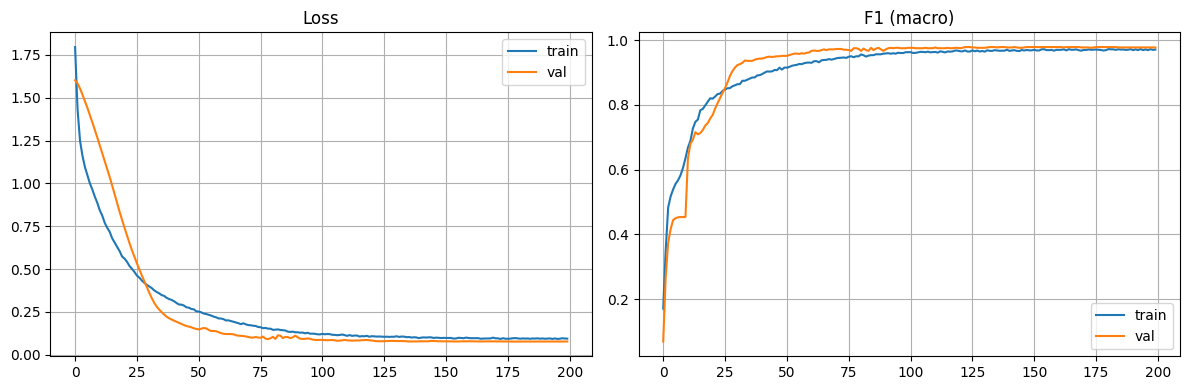

Training complete. Best val F1 = 0.9784 at epoch 138
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9289    0.8971    0.9127       204
           1     1.0000    0.9265    0.9618       204
           2     0.8020    0.9294    0.8610       170
           3     0.6431    0.8039    0.7146       204
           4     0.6667    0.4471    0.5352       170

    accuracy                         0.8088       952
   macro avg     0.8082    0.8008    0.7971       952
weighted avg     0.8134    0.8088    0.8041       952

Overall Accuracy: 0.8088
Macro Precision: 0.8082
Macro Recall:    0.8008
Macro F1:        0.7971
Macro F1: 0.7971



Fold: 1
Fold 1: Train users: 41, Val users: 5, Test users: 5
Train windows: 6872, Val windows: 816, Test windows: 816
Class weights: tensor([0.9838, 0.9852, 1.0365, 0.9859, 1.0106])
Total trainable parameters: 15875


Training: 100%|█████| 200/200 [00:31<00:00,  6.30epoch/s, TL=0.141, VL=0.499, VF1=0.835, best VF1=0.863, best Epoch=62]


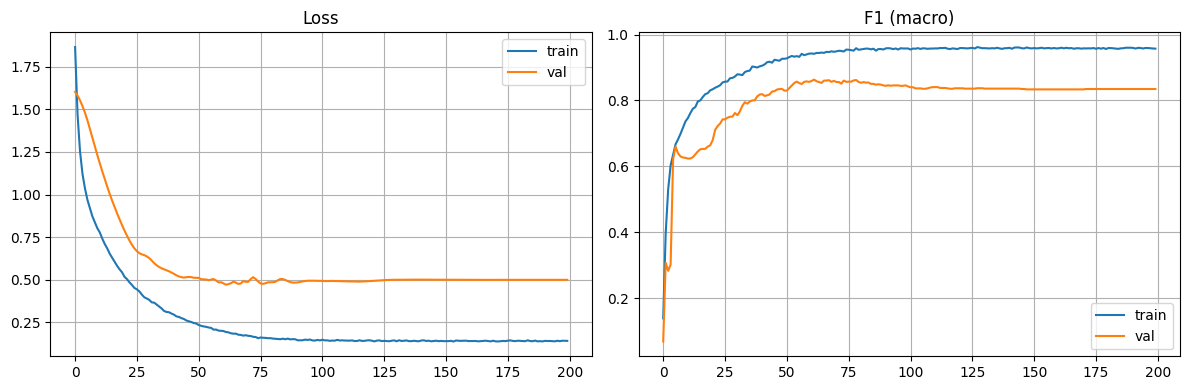

Training complete. Best val F1 = 0.8632 at epoch 62
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9602    0.9941    0.9769       170
           1     1.0000    0.9779    0.9888       136
           2     0.9939    0.9647    0.9791       170
           3     0.9884    1.0000    0.9942       170
           4     1.0000    1.0000    1.0000       170

    accuracy                         0.9877       816
   macro avg     0.9885    0.9874    0.9878       816
weighted avg     0.9880    0.9877    0.9878       816

Overall Accuracy: 0.9877
Macro Precision: 0.9885
Macro Recall:    0.9874
Macro F1:        0.9878
Macro F1: 0.9878



Fold: 2
Fold 2: Train users: 41, Val users: 5, Test users: 5
Train windows: 6872, Val windows: 816, Test windows: 816
Class weights: tensor([0.9838, 1.0098, 1.0106, 0.9859, 1.0106])
Total trainable parameters: 15875


Training: 100%|████| 200/200 [00:31<00:00,  6.32epoch/s, TL=0.071, VL=0.248, VF1=0.903, best VF1=0.912, best Epoch=110]


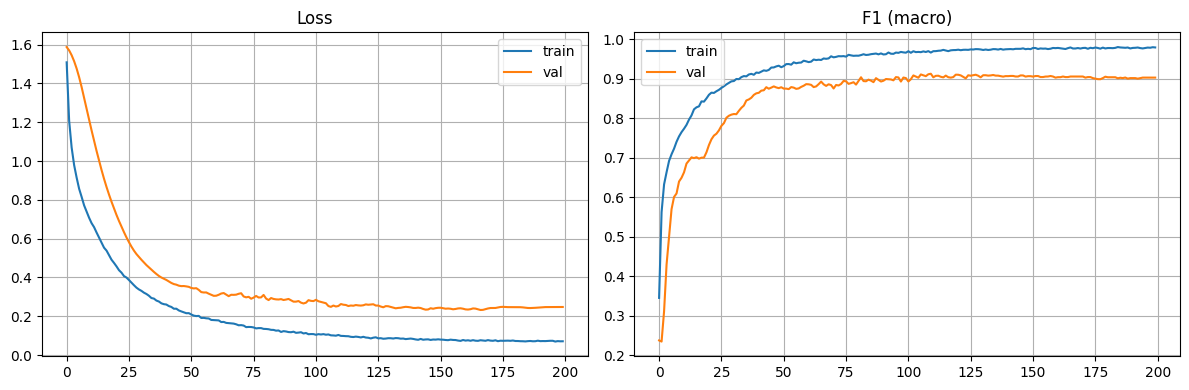

Training complete. Best val F1 = 0.9123 at epoch 110
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9071    0.7471    0.8194       170
           1     0.8333    1.0000    0.9091       170
           2     0.9333    0.8235    0.8750       136
           3     0.9172    0.7824    0.8444       170
           4     0.8116    0.9882    0.8912       170

    accuracy                         0.8701       816
   macro avg     0.8805    0.8682    0.8678       816
weighted avg     0.8783    0.8701    0.8675       816

Overall Accuracy: 0.8701
Macro Precision: 0.8805
Macro Recall:    0.8682
Macro F1:        0.8678
Macro F1: 0.8678



Fold: 3
Fold 3: Train users: 41, Val users: 5, Test users: 5
Train windows: 6836, Val windows: 852, Test windows: 816
Class weights: tensor([0.9794, 1.0053, 1.0311, 0.9808, 1.0053])
Total trainable parameters: 15875


Training: 100%|█████| 200/200 [00:30<00:00,  6.46epoch/s, TL=0.115, VL=0.502, VF1=0.820, best VF1=0.832, best Epoch=96]


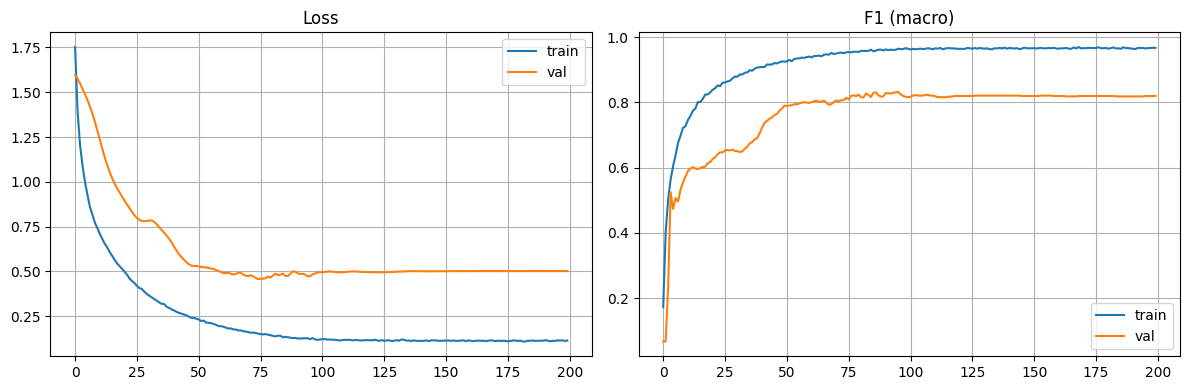

Training complete. Best val F1 = 0.8320 at epoch 96
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9866    0.8647    0.9216       170
           1     0.9882    0.9824    0.9853       170
           2     0.8897    0.9485    0.9181       136
           3     0.9043    1.0000    0.9497       170
           4     0.9636    0.9353    0.9493       170

    accuracy                         0.9461       816
   macro avg     0.9465    0.9462    0.9448       816
weighted avg     0.9488    0.9461    0.9459       816

Overall Accuracy: 0.9461
Macro Precision: 0.9465
Macro Recall:    0.9462
Macro F1:        0.9448
Macro F1: 0.9448



Fold: 4
Fold 4: Train users: 41, Val users: 5, Test users: 5
Train windows: 6801, Val windows: 851, Test windows: 852
Class weights: tensor([0.9751, 1.0001, 1.0528, 0.9758, 1.0001])
Total trainable parameters: 15875


Training: 100%|█████| 200/200 [00:31<00:00,  6.31epoch/s, TL=0.092, VL=0.459, VF1=0.823, best VF1=0.839, best Epoch=99]


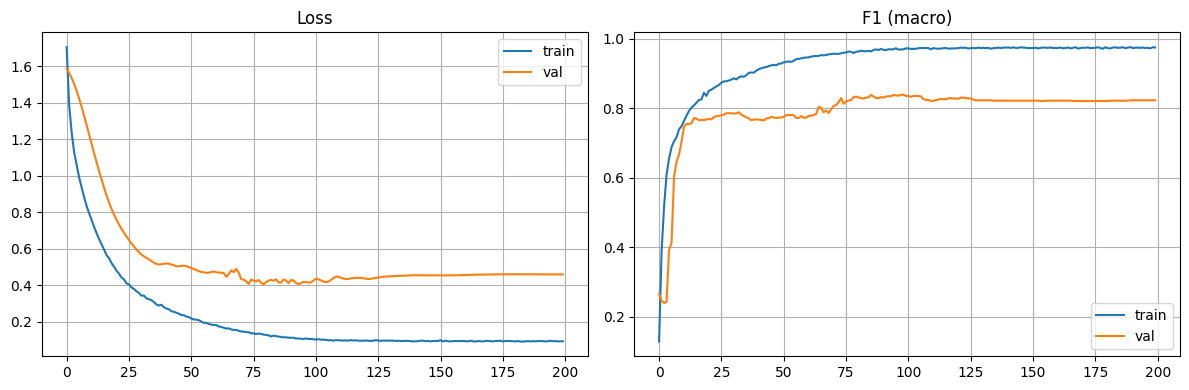

Training complete. Best val F1 = 0.8391 at epoch 99
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.8857    0.7251    0.7974       171
           1     0.9497    0.9942    0.9714       171
           2     0.8108    0.8824    0.8451       170
           3     0.7989    0.8882    0.8412       170
           4     0.8491    0.7941    0.8207       170

    accuracy                         0.8568       852
   macro avg     0.8588    0.8568    0.8552       852
weighted avg     0.8590    0.8568    0.8552       852

Overall Accuracy: 0.8568
Macro Precision: 0.8588
Macro Recall:    0.8568
Macro F1:        0.8552
Macro F1: 0.8552



Fold: 5
Fold 5: Train users: 41, Val users: 5, Test users: 5
Train windows: 6802, Val windows: 851, Test windows: 851
Class weights: tensor([0.9752, 0.9996, 1.0529, 0.9759, 1.0003])
Total trainable parameters: 15875


Training: 100%|████| 200/200 [00:31<00:00,  6.34epoch/s, TL=0.119, VL=0.277, VF1=0.907, best VF1=0.909, best Epoch=130]


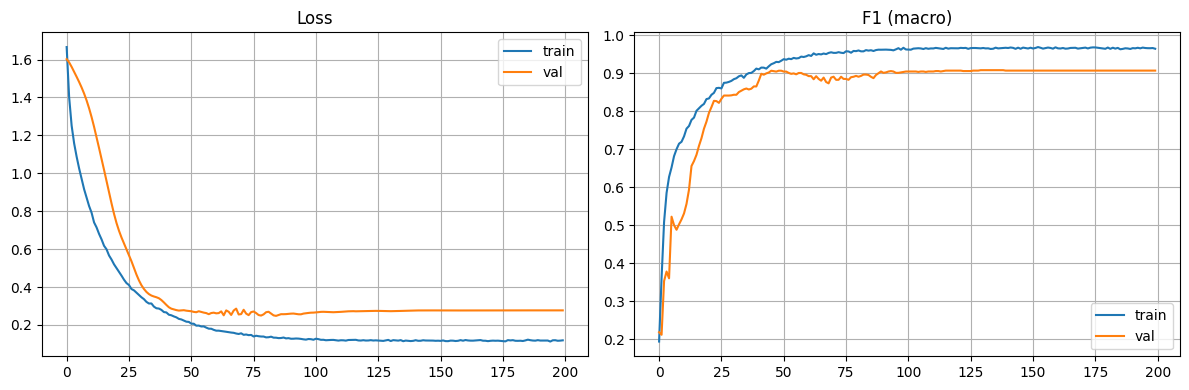

Training complete. Best val F1 = 0.9086 at epoch 130
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.8141    0.9474    0.8757       171
           1     0.9884    1.0000    0.9942       170
           2     0.7874    0.8059    0.7965       170
           3     0.8571    0.5294    0.6545       170
           4     0.7313    0.8647    0.7925       170

    accuracy                         0.8296       851
   macro avg     0.8357    0.8295    0.8227       851
weighted avg     0.8356    0.8296    0.8227       851

Overall Accuracy: 0.8296
Macro Precision: 0.8357
Macro Recall:    0.8295
Macro F1:        0.8227
Macro F1: 0.8227



Fold: 6
Fold 6: Train users: 41, Val users: 5, Test users: 5
Train windows: 6803, Val windows: 850, Test windows: 851
Class weights: tensor([0.9746, 0.9997, 1.0531, 0.9760, 1.0004])
Total trainable parameters: 15875


Training: 100%|████| 200/200 [00:31<00:00,  6.38epoch/s, TL=0.103, VL=0.234, VF1=0.890, best VF1=0.903, best Epoch=136]


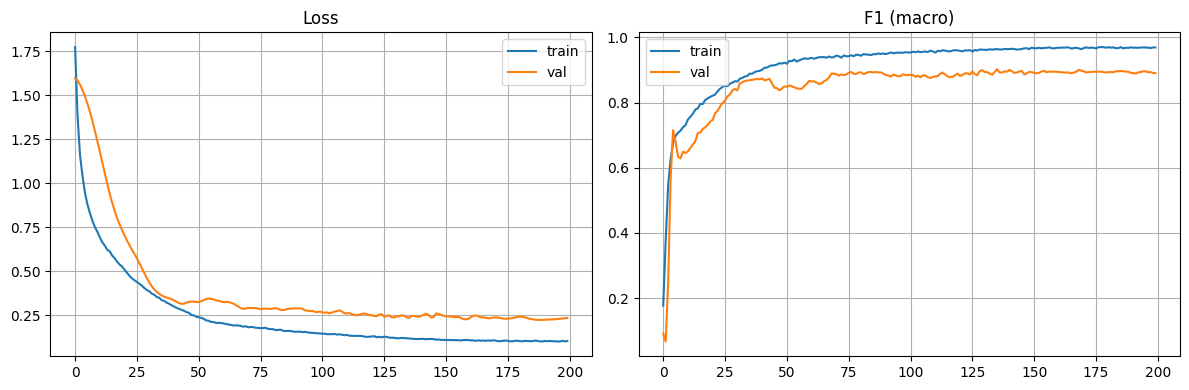

Training complete. Best val F1 = 0.9027 at epoch 136
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9040    0.9357    0.9195       171
           1     0.9827    1.0000    0.9913       170
           2     0.9273    0.9000    0.9134       170
           3     0.9563    0.9000    0.9273       170
           4     0.9148    0.9471    0.9306       170

    accuracy                         0.9365       851
   macro avg     0.9370    0.9365    0.9364       851
weighted avg     0.9369    0.9365    0.9364       851

Overall Accuracy: 0.9365
Macro Precision: 0.9370
Macro Recall:    0.9365
Macro F1:        0.9364
Macro F1: 0.9364



Fold: 7
Fold 7: Train users: 41, Val users: 5, Test users: 5
Train windows: 6804, Val windows: 850, Test windows: 850
Class weights: tensor([0.9741, 0.9999, 1.0533, 0.9762, 1.0006])
Total trainable parameters: 15875


Training: 100%|█████| 200/200 [00:31<00:00,  6.42epoch/s, TL=0.133, VL=0.457, VF1=0.835, best VF1=0.861, best Epoch=96]


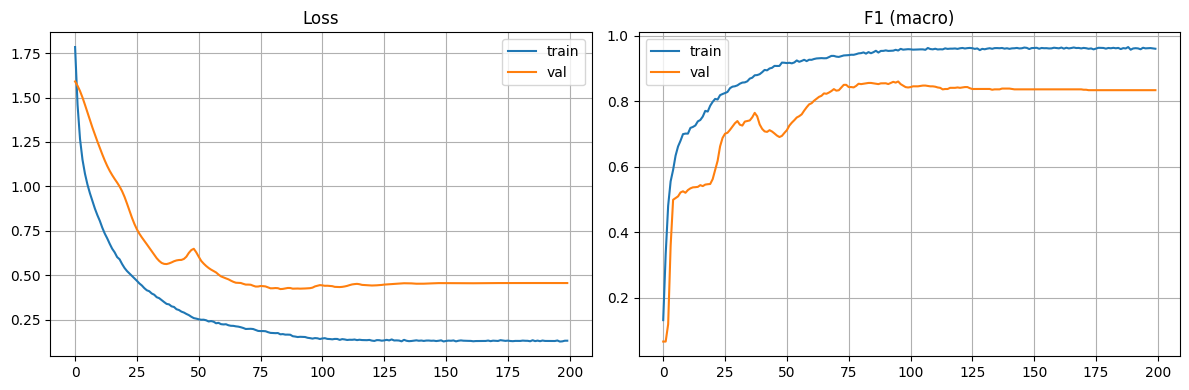

Training complete. Best val F1 = 0.8611 at epoch 96
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9133    0.9294    0.9213       170
           1     1.0000    1.0000    1.0000       170
           2     0.9383    0.8941    0.9157       170
           3     0.9542    0.8588    0.9040       170
           4     0.8646    0.9765    0.9171       170

    accuracy                         0.9318       850
   macro avg     0.9341    0.9318    0.9316       850
weighted avg     0.9341    0.9318    0.9316       850

Overall Accuracy: 0.9318
Macro Precision: 0.9341
Macro Recall:    0.9318
Macro F1:        0.9316
Macro F1: 0.9316



Fold: 8
Fold 8: Train users: 41, Val users: 5, Test users: 5
Train windows: 6804, Val windows: 850, Test windows: 850
Class weights: tensor([0.9741, 0.9999, 1.0533, 0.9762, 1.0006])
Total trainable parameters: 15875


Training: 100%|████| 200/200 [00:31<00:00,  6.35epoch/s, TL=0.075, VL=0.199, VF1=0.914, best VF1=0.941, best Epoch=113]


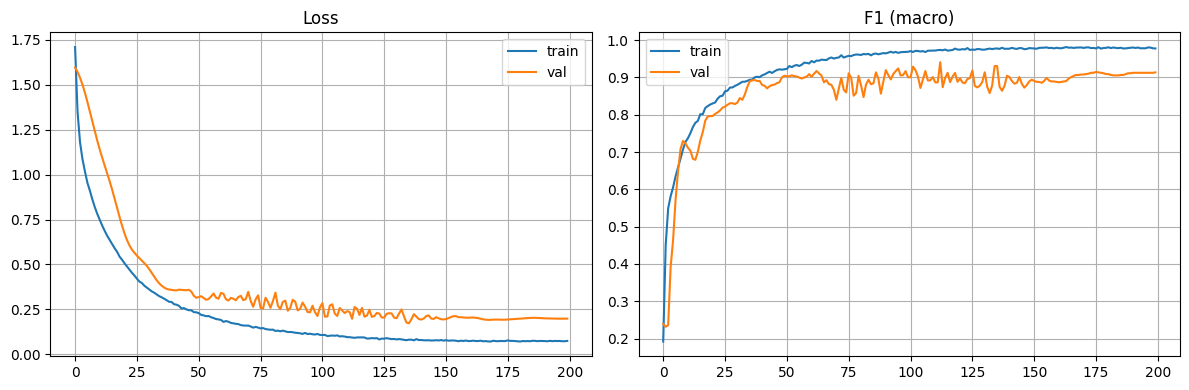

Training complete. Best val F1 = 0.9408 at epoch 113
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9816    0.9412    0.9610       170
           1     0.9824    0.9824    0.9824       170
           2     0.9486    0.9765    0.9623       170
           3     0.7658    0.7118    0.7378       170
           4     0.7337    0.7941    0.7627       170

    accuracy                         0.8812       850
   macro avg     0.8824    0.8812    0.8812       850
weighted avg     0.8824    0.8812    0.8812       850

Overall Accuracy: 0.8812
Macro Precision: 0.8824
Macro Recall:    0.8812
Macro F1:        0.8812
Macro F1: 0.8812



Fold: 9
Fold 9: Train users: 40, Val users: 6, Test users: 5
Train windows: 6702, Val windows: 952, Test windows: 850
Class weights: tensor([0.9834, 1.0101, 1.0375, 0.9856, 0.9856])
Total trainable parameters: 15875


Training: 100%|█████| 200/200 [00:31<00:00,  6.30epoch/s, TL=0.149, VL=0.533, VF1=0.801, best VF1=0.846, best Epoch=63]


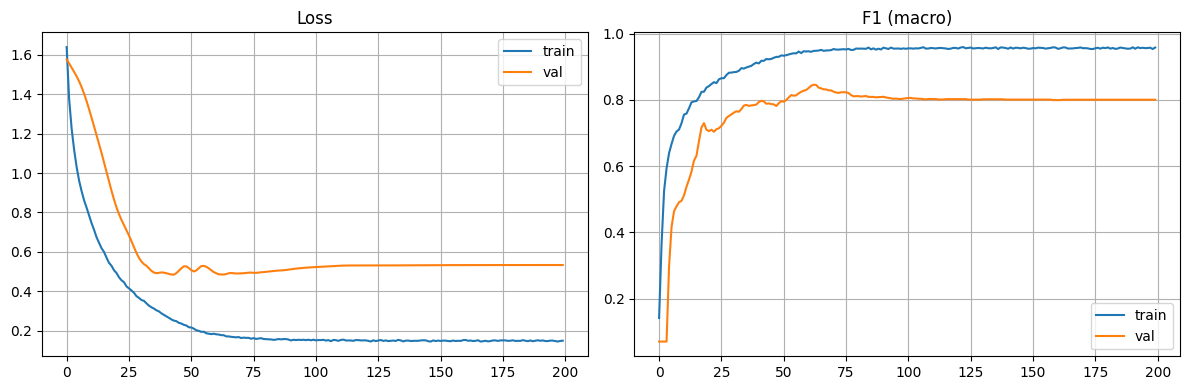

Training complete. Best val F1 = 0.8461 at epoch 63
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9919    0.7176    0.8328       170
           1     1.0000    0.9824    0.9911       170
           2     0.7742    0.9882    0.8682       170
           3     0.9045    0.9471    0.9253       170
           4     0.9394    0.9118    0.9254       170

    accuracy                         0.9094       850
   macro avg     0.9220    0.9094    0.9085       850
weighted avg     0.9220    0.9094    0.9085       850

Overall Accuracy: 0.9094
Macro Precision: 0.9220
Macro Recall:    0.9094
Macro F1:        0.9085
Macro F1: 0.9085



Mean macro f1 for test users: 0.8933
std macro f1 for test users: 0.0562


In [9]:
# Train by folds

f1_list = []

for fold in range(n_splits):
    print(f'\n\n\nFold: {fold}')
    
    model, X_test_scaled, y_test = train_by_fold(fold)
    
    f1 = evaluate_model(model, X_test_scaled, y_test, device='cpu')
    print(f"Macro F1: {f1:.4f}")
    f1_list.append(f1)

print(f'\n\n\nMean macro f1 for test users: {np.mean(f1_list):.4f}')
print(f'std macro f1 for test users: {np.std(f1_list):.4f}')